In [101]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

from wave_optics_propagation_enhanced.classical_numerics import (
    classical_numerics_simulation,
    thin_lens_simulation,
)
from wave_optics_propagation_enhanced.parameters import ExperimentParameters
from wave_optics_propagation_enhanced.result import ExperimentResult

In [102]:
# EXPERIMENT_ID = "2026-01-08_07-54-21" # reverse, various parameters
# EXPERIMENT_ID = "2026-01-08_08-41-00"  # forward, various parameters

# EXPERIMENT_ID = "2026-01-13_12-46-04"  # reverse, max_delta=0.05
# EXPERIMENT_ID = "2026-01-13_13-20-27"  # reverse, max_delta=0.01

# EXPERIMENT_ID = "2026-01-13_14-02-31"  # reverse, max_delta=0.01, longer z

EXPERIMENT_ID = "2026-01-16_10-06-45"  # non-fresnel, max_delta=0.1, check waist

# EXPERIMENT_ID = "2026-01-16_10-41-04"  # non-fresnel, max_delta=0.01, check waist

# EXPERIMENT_ID = "2026-01-19_11-20-01"

PATH_TO_RESULTS_FOLDER = f".result/{EXPERIMENT_ID}/"

## Pre-processing


In [103]:
params = ExperimentParameters.from_file(path=PATH_TO_RESULTS_FOLDER)
results = ExperimentResult.from_file(path=PATH_TO_RESULTS_FOLDER)
params

ExperimentParameters(vacuum_wavelength=1e-06, beam_FWHM=2e-05, focal_length=0.0002, refractive_index=1.25, propagation_after_lens=0.00030000000000000003, transverse_length=0.0001, num_of_steps_after_lens=300, lens_slices=10000, num_qubits=6, max_delta=0.1, lens_reverse_order=False, fresnel_approximation=False, scale_down_phases=True, experiment_datetime=datetime.datetime(2026, 1, 16, 10, 6, 45, 316525))

In [104]:
snapshots = results.snapshots


def process_statevector(statevector: np.ndarray) -> np.ndarray:
    return statevector.flatten()


initial_statevector = process_statevector(snapshots[f"step_{0}"])

lens_statevectors = [
    process_statevector(snapshots[f"step_lens_{i}"])
    if f"step_lens_{i}" in snapshots
    else None
    for i in range(params.lens_slices)
]
after_lens_statevectors = [
    process_statevector(snapshots[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in snapshots
    else None
    for i in range(params.num_of_steps_after_lens)
]

In [105]:
for i in range(params.lens_slices):
    if f"step_lens_{i}" not in snapshots:
        print(f"{i}")

for i in range(params.num_of_steps_after_lens):
    if f"step_after_lens_{i + 1}" not in snapshots:
        print(f"{i + 1}")

In [106]:
# classical_numerics_statevectors = []
analytical_thin_lens_after_lens_statevectors = []
analytical_thin_lens_in_lens_statevectors = []


# We first calculate the positions of the principle plane
principle_plane_position = (
    params.lens_thickness
    if params.lens_reverse_order
    else (params.lens_thickness - params.lens_thickness / params.refractive_index)
)

# the case inside the lens. because the principle plane is either inside the lens or at the end of the lens, we have to check this in the loop
for i in range(params.lens_slices):
    z = params.lens_slice_thickness * (i + 1)

    if z < principle_plane_position:
        analytical_result = thin_lens_simulation(
            params,
            propagation_before_lens=z,
            propagation_after_lens=0,
        )
        analytical_thin_lens_in_lens_statevectors.append(analytical_result)

    else:
        analytical_result = thin_lens_simulation(
            params,
            propagation_before_lens=principle_plane_position,
            propagation_after_lens=z - principle_plane_position,
        )
        analytical_thin_lens_in_lens_statevectors.append(analytical_result)

for i in range(params.num_of_steps_after_lens):
    after_lens_distance = params.step_size_after_lens * (i + 1)
    distance_from_principle_plane = (
        params.lens_thickness - principle_plane_position
    ) + after_lens_distance

    analytical_result = thin_lens_simulation(
        params,
        propagation_before_lens=principle_plane_position,
        propagation_after_lens=distance_from_principle_plane,
    )

    analytical_thin_lens_after_lens_statevectors.append(analytical_result)

In [107]:
full_sim_statevectors = lens_statevectors + after_lens_statevectors

full_analytical_thin_lens_statevectors = (
    analytical_thin_lens_in_lens_statevectors
    + analytical_thin_lens_after_lens_statevectors
)

z_axis = [params.lens_slice_thickness * (i + 1) for i in range(params.lens_slices)] + [
    params.lens_thickness + params.step_size_after_lens * (i + 1)
    for i in range(params.num_of_steps_after_lens)
]

## Wavefunction plots


Plotting initial state


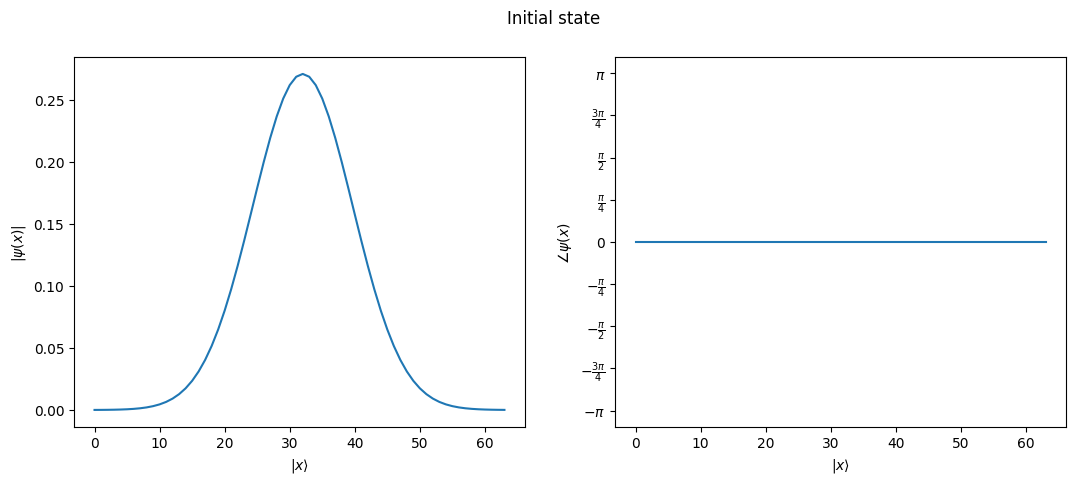

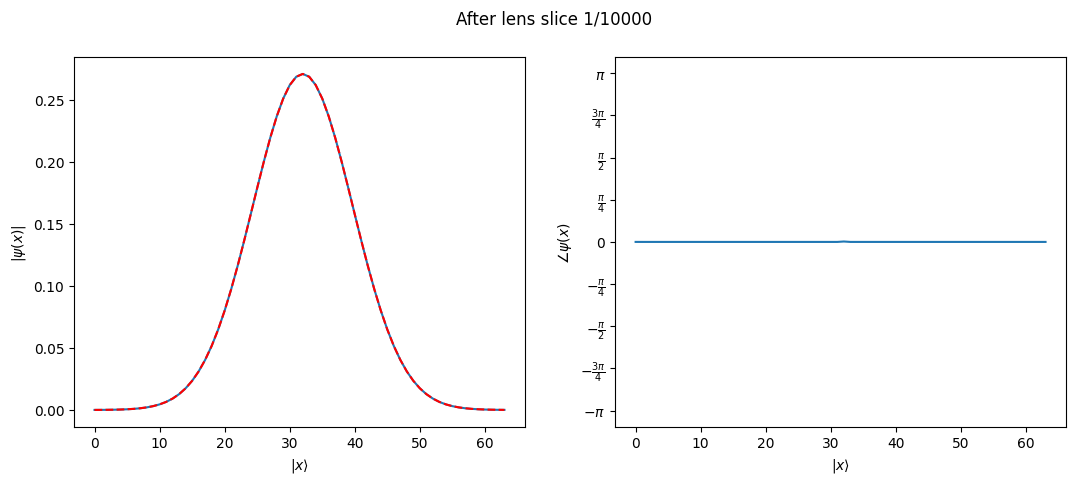

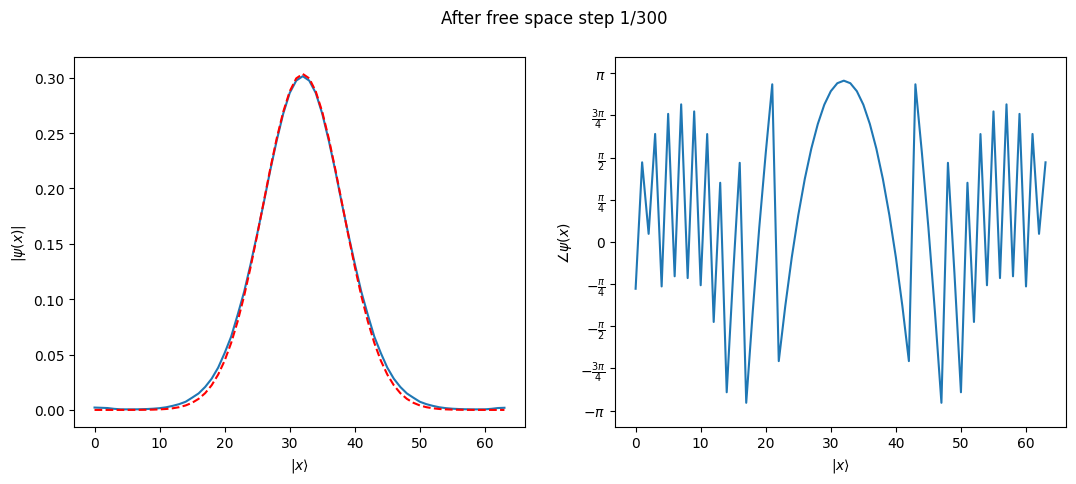

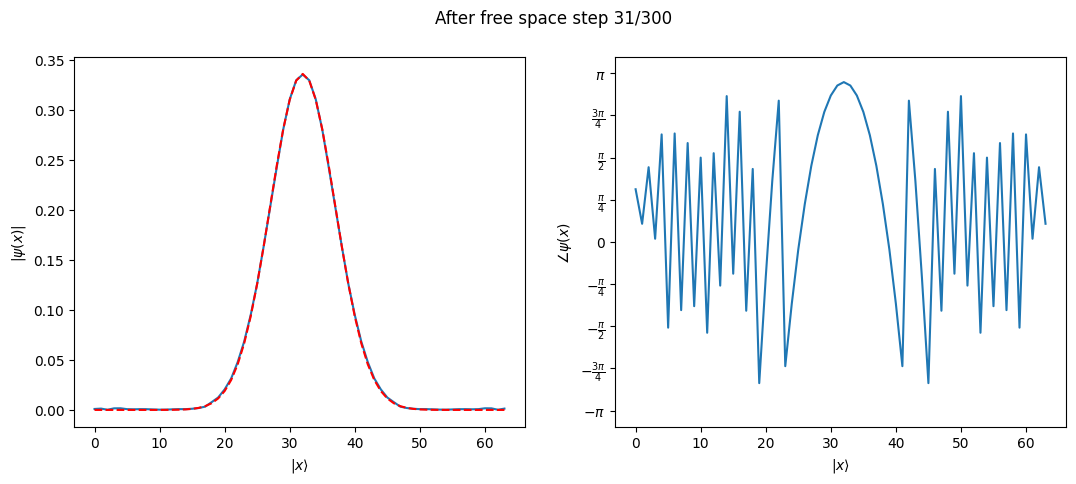

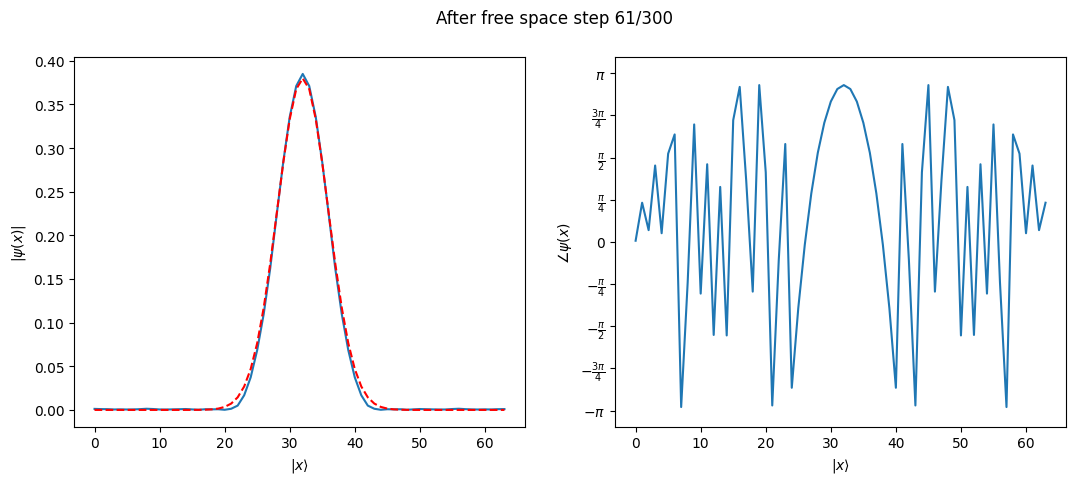

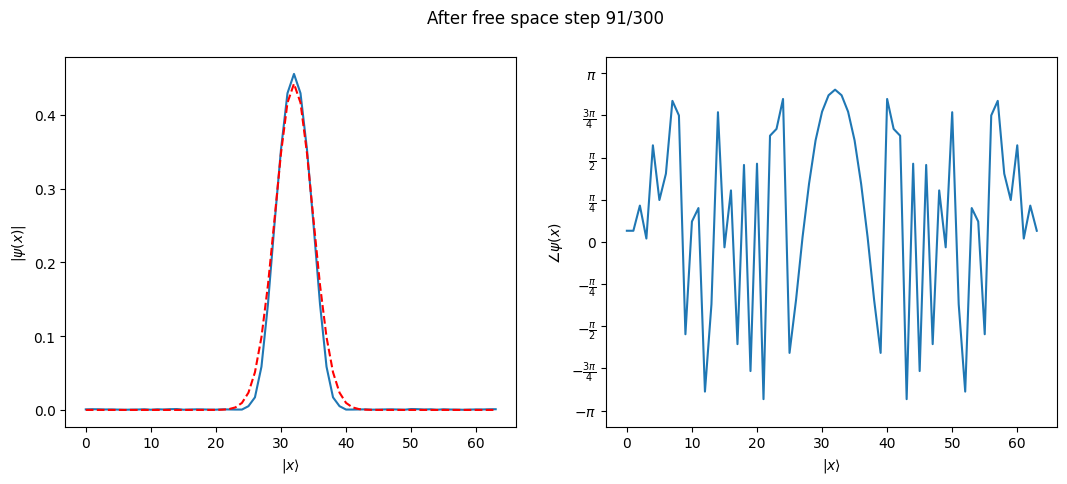

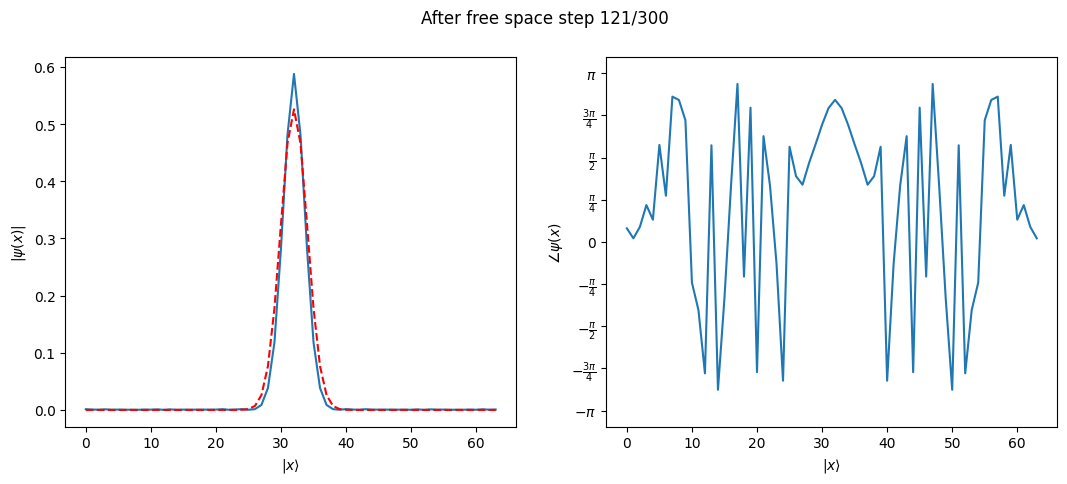

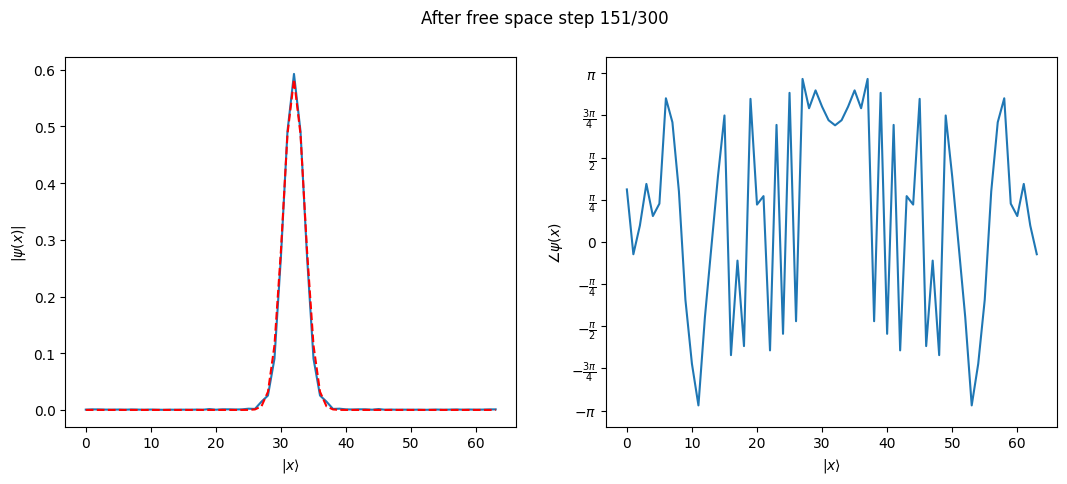

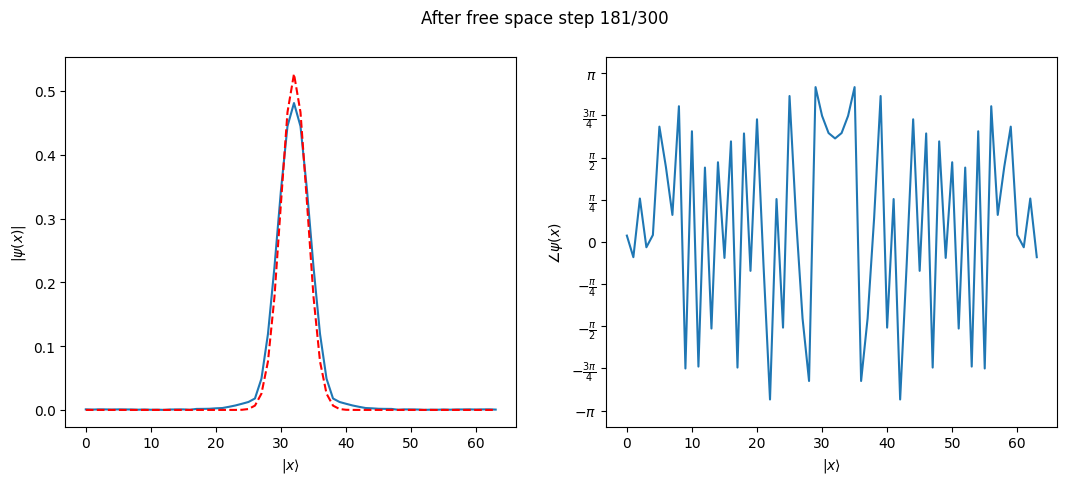

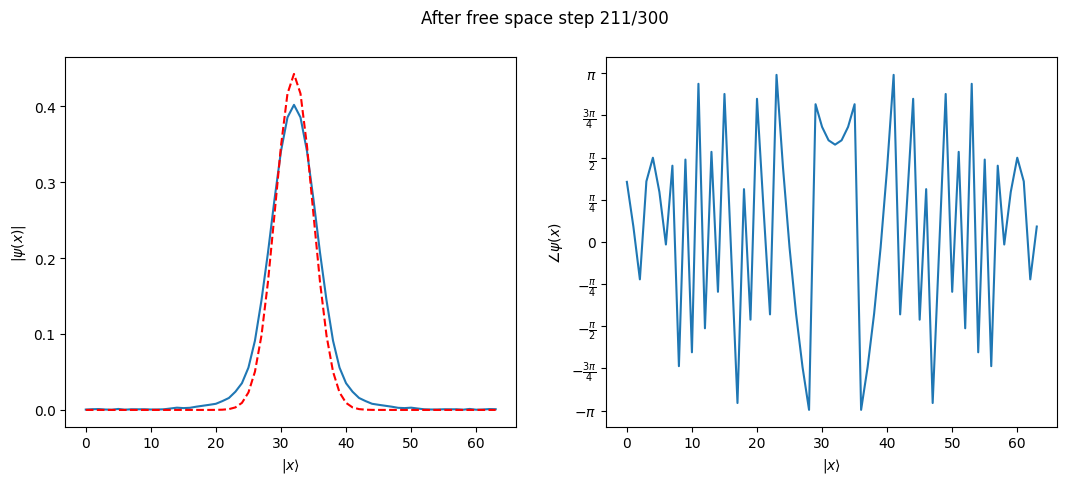

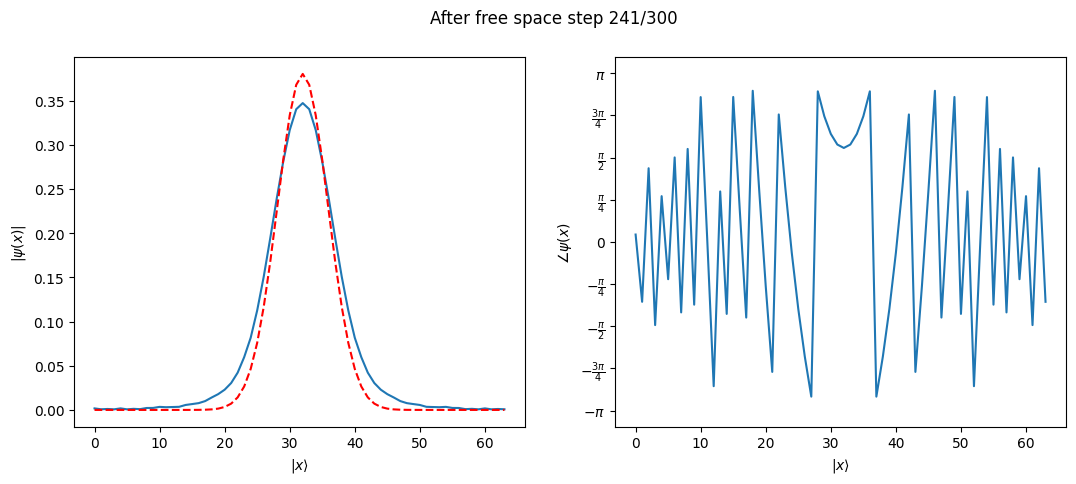

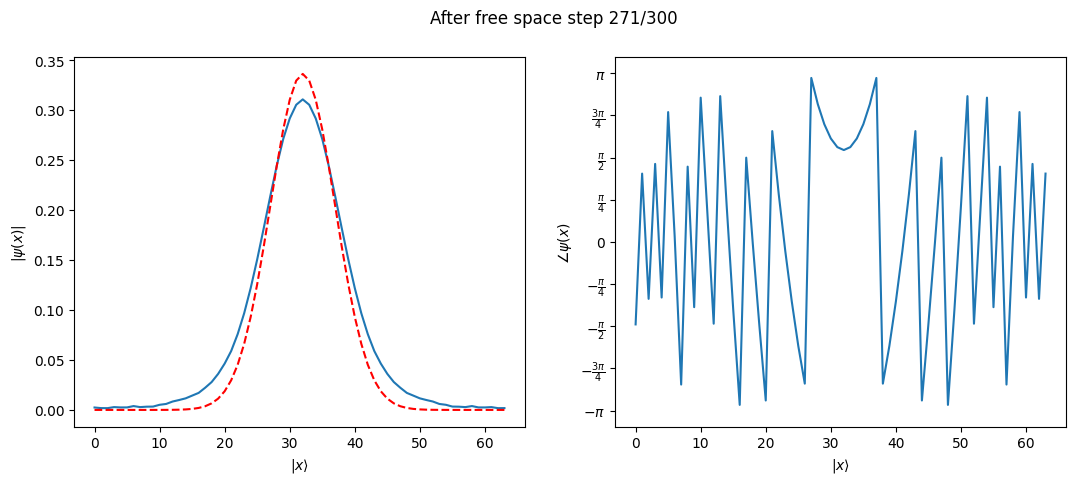

In [108]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 1
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 10

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        results.total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (results.total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    # print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    ax1.plot(
        np.abs(analytical_thin_lens_in_lens_statevectors[i]),
        "r--",
        label="thin lens analytical",
    )

    plt.suptitle(f"After lens slice {i + 1}/{params.lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (params.num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    # print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    # classical_numerics_result = classical_numerics_simulation(
    #     params, propagation_after_lens=after_lens_distance
    # )

    ax1.plot(
        np.abs(analytical_thin_lens_after_lens_statevectors[i]),
        "r--",
        label="thin lens analytical",
    )

    # ax1.plot(np.abs(classical_numerics_result), "g--", label="classical numerics")

    plt.suptitle(f"After free space step {i + 1}/{params.num_of_steps_after_lens}")
    plt.show()

## Beam waist plots


In [109]:
# map each statevector after lens to its corresponding beam waist

# TODO: verify beam waist calculation
def map_statevector_to_beam_waist(statevector: np.ndarray) -> float:
    intensity = np.abs(statevector) ** 2
    total_intensity = np.sum(intensity)
    x_mean = np.sum(params.x_axis.axis_values * intensity) / total_intensity
    x2_mean = np.sum((params.x_axis.axis_values**2) * intensity) / total_intensity
    variance = x2_mean - x_mean**2
    beam_waist = np.sqrt(variance) * 2  # beam waist approximation
    return beam_waist


analytical_beam_waists = [
    map_statevector_to_beam_waist(statevector)
    for statevector in full_analytical_thin_lens_statevectors
]

# classical_numerics_beam_waists = []

beam_waists = [
    map_statevector_to_beam_waist(statevector)
    for statevector in full_sim_statevectors
    if statevector is not None
]

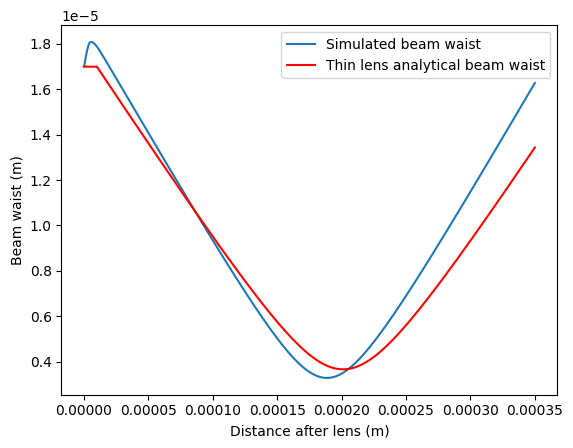

In [110]:
# from wave_optics_propagation.BeamProp_Script import prop, q1_inv_func

# plot beam waists
plt.plot(
    z_axis,
    beam_waists,
    "-",
    label="Simulated beam waist",
)

plt.plot(
    z_axis,
    analytical_beam_waists,
    "r-",
    label="Thin lens analytical beam waist",
)

# plt.plot(
#     distance_axis,
#     classical_numerics_beam_waists,
#     "g-",
#     label="Classical numerics beam waist",
# )


# plt.axvline(
#     x=ideal_focal_point,
#     color="black",
#     linestyle="--",
#     label="Ideal focal point",
# )
# plt.axhline(
#     y=beam_waist_after_lens,
#     color="gray",
#     linestyle="--",
#     label="Initial beam waist",
# )

plt.xlabel("Distance after lens (m)")
plt.ylabel("Beam waist (m)")
plt.legend()
plt.show()

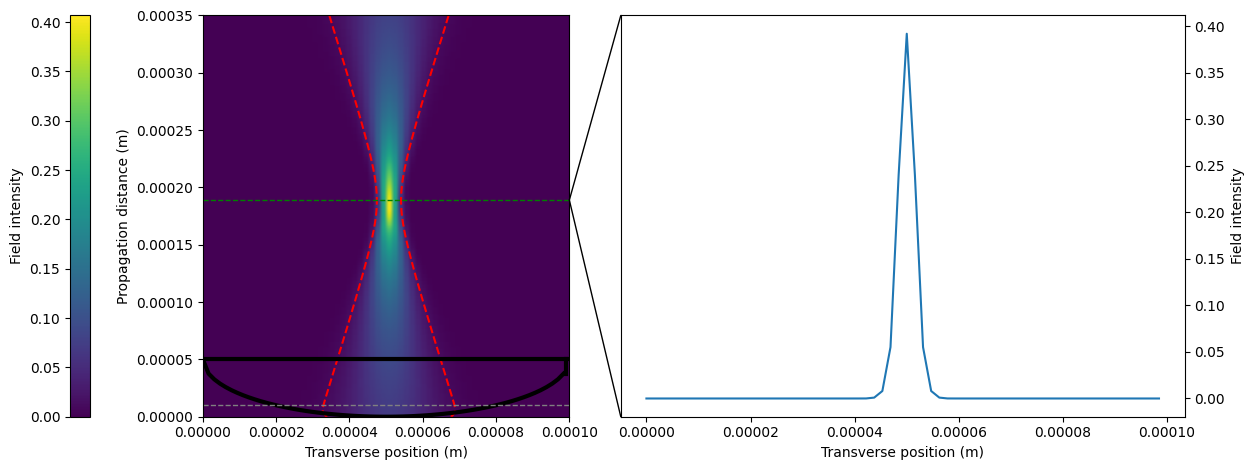

In [111]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, (ax_color_plot, ax_field) = plt.subplots(1, 2, figsize=(2 * 6.4, 1 * 4.8))

vmin = 0
vmax = (
    np.max(
        [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None]
    )
    + 0.01
)

im1 = ax_color_plot.imshow(
    [np.abs(state) ** 2 for state in lens_statevectors if state is not None],
    extent=(0.0, params.transverse_length, 0.0, params.lens_thickness),
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)

im2 = ax_color_plot.imshow(
    [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None],
    extent=(
        0.0,
        params.transverse_length,
        params.lens_thickness,
        params.lens_thickness + params.propagation_after_lens,
    ),
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)
ax_color_plot.set_ylim(0, params.lens_thickness + params.propagation_after_lens)
ax_color_plot.set_xlim(0.0, params.transverse_length)

middle_point = params.transverse_length / 2 + params.delta_x / 2
ax_color_plot.plot(
    middle_point + np.array(beam_waists),
    z_axis,
    "r--",
    label="Beam waist",
)

ax_color_plot.plot(
    middle_point - np.array(beam_waists),
    z_axis,
    "r--",
)

if params.lens_reverse_order:
    y = (
        params.lens_thickness
        - (params.x_axis.axis_values - params.transverse_length / 2) ** 2
        / (2 * params.radius_of_curvature)
        if params.fresnel_approximation is True
        else params.lens_thickness
        + np.sqrt(
            params.radius_of_curvature**2
            - (params.lens_radius - params.x_axis.axis_values) ** 2
        )
        - params.radius_of_curvature
    )
    ax_color_plot.plot(
        params.x_axis.axis_values, y, color="black", lw=3, ls="-", label="Lens surface"
    )
    ax_color_plot.axhline(z_axis[0], color="black", lw=8, ls="-")
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[0],
            params.x_axis.axis_values[0],
        ],
        [0, y[0]],
        color="black",
        lw=6,
        ls="-",
    )
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[-1] + params.delta_x / 2,
            params.x_axis.axis_values[-1] + params.delta_x / 2,
        ],
        [0, y[-1]],
        color="black",
        lw=3,
        ls="-",
    )
else:
    y = (
        (params.x_axis.axis_values - params.transverse_length / 2) ** 2
        / (2 * params.radius_of_curvature)
        if params.fresnel_approximation is True
        else params.radius_of_curvature
        - np.sqrt(
            params.radius_of_curvature**2
            - (params.lens_radius - params.x_axis.axis_values) ** 2
        )
    )
    ax_color_plot.plot(
        params.x_axis.axis_values, y, color="black", lw=3, ls="-", label="Lens surface"
    )
    ax_color_plot.axhline(params.lens_thickness, color="black", lw=3, ls="-")
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[0],
            params.x_axis.axis_values[0],
        ],
        [params.lens_thickness, y[0]],
        color="black",
        lw=6,
        ls="-",
    )
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[-1] + params.delta_x / 2,
            params.x_axis.axis_values[-1] + params.delta_x / 2,
        ],
        [params.lens_thickness, y[-1]],
        color="black",
        lw=3,
        ls="-",
    )


ax_color_plot.set_xlabel("Transverse position (m)")
ax_color_plot.set_ylabel("Propagation distance (m)")


focal_point_index = np.argmin(beam_waists)
focal_point = z_axis[focal_point_index]
focal_statevector = full_sim_statevectors[focal_point_index]

ax_field.plot(
    params.x_axis.axis_values,
    np.abs(focal_statevector) ** 2,
    label="Simulated intensity at focal point",
)
ax_field.yaxis.tick_right()
ax_field.yaxis.set_label_position("right")

ax_field.set_xlabel("Transverse position (m)")
ax_field.set_ylabel("Field intensity")

ax_color_plot.axhline(focal_point, color="green", lw=1, ls="--", label="Focal point")

from matplotlib.patches import ConnectionPatch

zoom_xlim = (0, params.transverse_length)
zoom_ylim = (focal_point, focal_point)


con1 = ConnectionPatch(
    xyA=(params.transverse_length, focal_point),
    axesA=ax_color_plot,
    coordsA="data",
    xyB=(0, 1),
    axesB=ax_field,
    coordsB="axes fraction",
    color="black",
)

con2 = ConnectionPatch(
    xyA=(params.transverse_length, focal_point),
    axesA=ax_color_plot,
    coordsA="data",
    xyB=(0, 0),
    axesB=ax_field,
    coordsB="axes fraction",
    color="black",
)

ax_color_plot.axhline(
    principle_plane_position, color="gray", lw=1, ls="--", label="Principle plane"
)

fig.add_artist(con1)
fig.add_artist(con2)

cbar = fig.colorbar(
    im1, ax=ax_color_plot, label="Field intensity", pad=0.2, location="left"
)
# cbar.ax.set_position((0, 0, 0, 0))

fig.tight_layout()
# fig.colorbar(img, ax=ax, label="Field intensity")

In [112]:
focal_point

np.float64(0.000189)

In [113]:
0.000239 - 0.0001955

4.35e-05

In [114]:
params.lens_thickness / params.refractive_index

np.float64(4e-05)